<a href="https://colab.research.google.com/github/MichieRulz/DeepLearning/blob/main/Copy_of_Boxing_Punch_Detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')
import os
from sklearn.preprocessing import LabelEncoder

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
print(os.listdir("/content/drive/MyDrive/DeepLearningFinal/MotionDetect"))

['Lead_uppercut (1).csv', 'Rear_uppercut (1).csv', 'Lead_jab (1).csv', 'Lead_hook (1).csv', 'Rear_hook (1).csv', 'Rear_jab (1).csv', 'Rear_hook.csv', 'Lead_jab.csv', 'Lead_hook.csv', 'Rear_uppercut.csv', 'Rear_jab.csv', 'Lead_uppercut.csv', 'Boxing Punch Detector.ipynb', 'Rear_uppercut', 'Lead_jab', 'Lead_hook', 'Lead_uppercut', 'Rear_jab']


In [10]:
#mount google drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
#path info for csv file
folder_path = "/content/drive/MyDrive/DeepLearningFinal/MotionDetect'"

In [12]:
folder_path = "/content/drive/MyDrive/DeepLearningFinal/MotionDetect"
files = os.listdir(folder_path)

In [13]:
#load CSV files
df_list = []
standard_feature_columns = ['gyrx(deg/s)', 'gyry(deg/s)', 'gyrz(deg/s)', 'accx(g)', 'accy(g)', 'accz(g)']

for file_name in os.listdir(folder_path):
    if file_name.endswith('.csv'):
        label = file_name.replace('.csv', '').replace(' (1)', '')
        file_path = os.path.join(folder_path, file_name)

        try:
            # Read the CSV
            temp_df = pd.read_csv(file_path, skiprows=1, header=None)


            if temp_df.shape[1] >= 6:
                temp_df_features = temp_df.iloc[:, :6].copy()

                # Assign standard feature names to these 6 columns
                temp_df_features.columns = standard_feature_columns

                # Add the label column
                temp_df_features['label'] = label
                df_list.append(temp_df_features)
            else:
                print(f"Warning: {file_name} has fewer than 6 columns for features and its data might be incomplete or was skipped.")
        except Exception as e:
            print(f"Error reading {file_name}: {e}")

In [14]:
#combine into one
df = pd.concat(df_list, ignore_index=True)

print(df.head())
print(df.shape)

   gyrx(deg/s)  gyry(deg/s)  gyrz(deg/s)  accx(g)  accy(g)  accz(g)  \
0       24.085      -12.866       -7.744    0.692   -0.543    0.538   
1       23.720      -12.500       -8.720    0.697   -0.547    0.526   
2       24.024      -12.439       -9.756    0.692   -0.558    0.515   
3       24.634      -12.622      -10.671    0.682   -0.572    0.498   
4       25.305      -13.110      -11.463    0.677   -0.587    0.478   

           label  
0  Lead_uppercut  
1  Lead_uppercut  
2  Lead_uppercut  
3  Lead_uppercut  
4  Lead_uppercut  
(552118, 7)


In [15]:
#clean
df.columns = df.columns.str.strip()

In [16]:
#conver
for col in standard_feature_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows
df.dropna(subset=standard_feature_columns, inplace=True)

# --- Diagnostic Start ---
print("df after numeric conversion and dropna:")
print(df.head())
print("df dtypes after numeric conversion and dropna:")
print(df.dtypes)
# --- Diagnostic End ---

df after numeric conversion and dropna:
   gyrx(deg/s)  gyry(deg/s)  gyrz(deg/s)  accx(g)  accy(g)  accz(g)  \
0       24.085      -12.866       -7.744    0.692   -0.543    0.538   
1       23.720      -12.500       -8.720    0.697   -0.547    0.526   
2       24.024      -12.439       -9.756    0.692   -0.558    0.515   
3       24.634      -12.622      -10.671    0.682   -0.572    0.498   
4       25.305      -13.110      -11.463    0.677   -0.587    0.478   

           label  
0  Lead_uppercut  
1  Lead_uppercut  
2  Lead_uppercut  
3  Lead_uppercut  
4  Lead_uppercut  
df dtypes after numeric conversion and dropna:
gyrx(deg/s)    float64
gyry(deg/s)    float64
gyrz(deg/s)    float64
accx(g)        float64
accy(g)        float64
accz(g)        float64
label           object
dtype: object


In [17]:
#split labels and features
X = df.iloc[:, :-1]
Y = df.iloc[:, -1]

In [18]:
#encode string labels to numeric
le = LabelEncoder()
Y = le.fit_transform(Y)

In [19]:
#split
if not X.empty and Y.size > 0:
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
else:
    print("Error: X or Y are empty. Please check your data preprocessing steps, especially the `df.dropna()` call.")
    # Initialize empty tensors
    num_features = X.shape[1] if not X.empty else 0
    X_train = torch.empty((0, num_features), dtype=torch.float32)
    X_test = torch.empty((0, num_features), dtype=torch.float32)
    Y_train = torch.empty((0,), dtype=torch.long)
    Y_test = torch.empty((0,), dtype=torch.long)

In [20]:
#convert to PyTorch tensors
X_train = torch.tensor(X_train.values, dtype=torch.float32)
Y_train = torch.tensor(Y_train, dtype=torch.long)
X_test = torch.tensor(X_test.values, dtype=torch.float32)
Y_test = torch.tensor(Y_test, dtype=torch.long)

In [21]:
#normalize
X_train = (X_train - X_train.mean()) / X_train.std()
X_test = (X_test - X_test.mean()) / X_test.std()

In [22]:
#model
class MotionClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(MotionClassifier, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out
model = MotionClassifier(input_size=X_train.shape[1], hidden_size=64, num_classes=len(torch.unique(Y_train)))

In [23]:
#loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [24]:
#training
losses = []
epochs = 20
for epoch in range(epochs):
    model.train()
    outputs = model(X_train)
    print("outputs shape:", outputs.shape)
    print("Y_train shape:", Y_train.shape)
    print("Y_train unique values:", torch.unique(Y_train))

    loss = criterion(outputs, Y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    if (epoch+1) % 5 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

outputs shape: torch.Size([441694, 6])
Y_train shape: torch.Size([441694])
Y_train unique values: tensor([0, 1, 2, 3, 4, 5])
outputs shape: torch.Size([441694, 6])
Y_train shape: torch.Size([441694])
Y_train unique values: tensor([0, 1, 2, 3, 4, 5])
outputs shape: torch.Size([441694, 6])
Y_train shape: torch.Size([441694])
Y_train unique values: tensor([0, 1, 2, 3, 4, 5])
outputs shape: torch.Size([441694, 6])
Y_train shape: torch.Size([441694])
Y_train unique values: tensor([0, 1, 2, 3, 4, 5])
outputs shape: torch.Size([441694, 6])
Y_train shape: torch.Size([441694])
Y_train unique values: tensor([0, 1, 2, 3, 4, 5])
Epoch [5/20], Loss: 1.8114
outputs shape: torch.Size([441694, 6])
Y_train shape: torch.Size([441694])
Y_train unique values: tensor([0, 1, 2, 3, 4, 5])
outputs shape: torch.Size([441694, 6])
Y_train shape: torch.Size([441694])
Y_train unique values: tensor([0, 1, 2, 3, 4, 5])
outputs shape: torch.Size([441694, 6])
Y_train shape: torch.Size([441694])
Y_train unique values: 

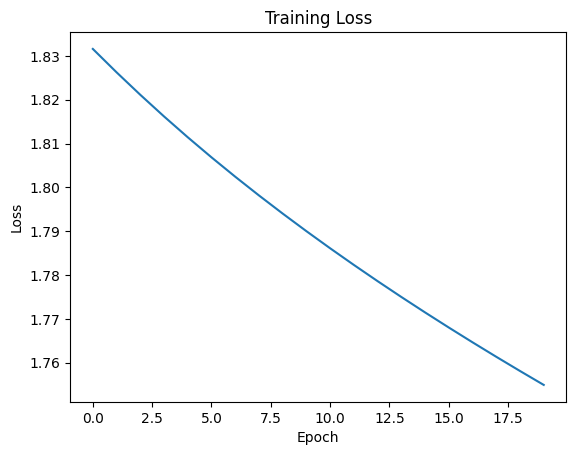

In [25]:
#plot loss
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

In [26]:
#testing
model.eval()
with torch.no_grad():
    test_outputs = model(X_test)
    _, predicted = torch.max(test_outputs.data, 1)
    accuracy = (predicted == Y_test).sum().item() / Y_test.size(0)
    print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.2971
